In [1]:
import numpy as np
from scipy.optimize import curve_fit
import torch
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

In [2]:
acu_subject = {}
for acronym_test in ['VISa5', 'DG-mo']:
    acu_subject[acronym_test] = torch.load(f'/content/drive/MyDrive/Project/Code/BrainRegionID/Project43_Result0/acu_subject_{acronym_test}.pt')[acronym_test]

In [3]:
def exp_func(x, a, b, x0):
    return -1 * np.exp(-a * (x - x0)) + b

def lin_func(x, a, b):
    return a * x + b

In [4]:
acu_subject['DG-mo'][0]

[tensor(0.4529),
 tensor(0.2865),
 tensor(0.2352),
 tensor(0.3454),
 tensor(0.2554)]

In [5]:
acu_subject_dict = {}
acronym_subject = []
accu = []
subject_num = []

sample_number = np.concatenate([5 * ii * np.ones(5) for ii in range(1, 8)])
for acronym_ii, acronym_test in enumerate(['VISa5', 'DG-mo']):
    for sample_ii, sample in enumerate(acu_subject[acronym_test]):
        for v in sample:
            accu.append(v)
            subject_num.append((sample_ii + 1) * 5)
            acronym_subject.append(acronym_test)

acu_subject_dict = pd.DataFrame(
    {
        'accu': np.array(accu),
        'acronym': np.array(acronym_subject),
        'subject_num': np.array(subject_num),
    }
)

Text(0, 0.5, 'cross-subject accuracy')

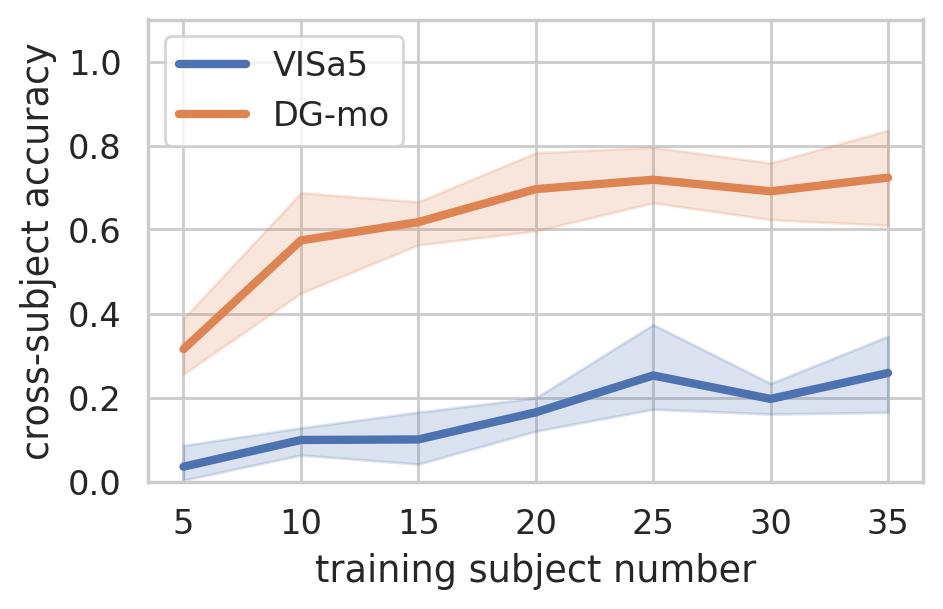

In [23]:
sns.set_theme(rc={'figure.dpi': 200, 'figure.figsize': (5, 3)}, style='whitegrid', font_scale=1.1)
g = sns.lineplot(data=acu_subject_dict, x='subject_num', y='accu', hue='acronym', linewidth=3)
# g.legend.set_title('acronym')
plt.legend(loc='upper left')
# sample_number = np.concatenate([5 * ii * np.ones(5) for ii in range(1, 8)])
# for acronym_ii, acronym_test in enumerate(['VISa5', 'DG-mo']):
#     acu = np.concatenate(acu_subject[acronym_test])

#     popt, pcov = curve_fit(exp_func, sample_number, acu, p0=[1/100, 1/472, 0], bounds=([0, 0.0, 0], [np.inf, 1., np.inf]))
#     print(popt)
#     print(1/len(acu) * np.sqrt(np.sum(np.square(exp_func(sample_number, *popt) - acu))))
#     plt.plot(sample_number, exp_func(sample_number, *popt), '-', color='black', linewidth=2.5, alpha=0.9, label=acronym_test)
#     plt.plot([0, 40], [popt[1], popt[1]], 'k--')

plt.ylim([0, 1.1])
plt.xlabel('training subject number')
plt.ylabel('cross-subject accuracy')

[8.78116089e-03 1.00000000e+00 1.14421151e-14]
0.013325514294682027
[1.85165252e-01 7.13016279e-01 2.65934150e-20]
0.017199150344262212


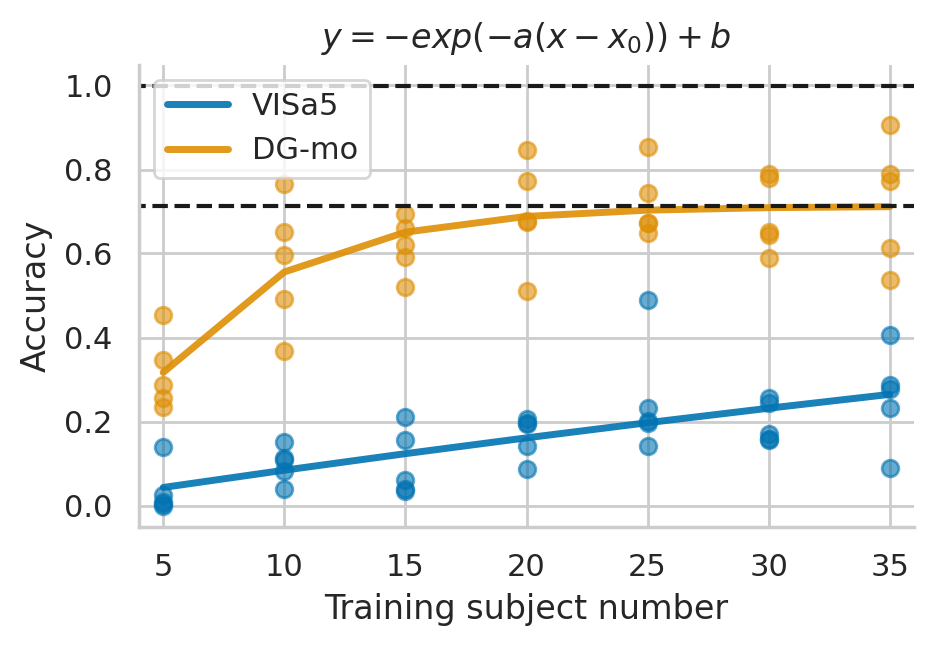

In [27]:
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(5, 3), dpi=200)
sample_number = np.concatenate([5 * ii * np.ones(5) for ii in range(1, 8)])
for acronym_ii, acronym_test in enumerate(['VISa5', 'DG-mo']):
    acu = np.concatenate(acu_subject[acronym_test])

    plt.scatter(sample_number, acu, color=color_list[acronym_ii], alpha=0.6)
    popt, pcov = curve_fit(exp_func, sample_number, acu, p0=[1/100, 1.0, 0], bounds=([0, 0.0, 0], [np.inf, 1., np.inf]))
    print(popt)
    print(1/len(acu) * np.sqrt(np.sum(np.square(exp_func(sample_number, *popt) - acu))))
    plt.plot(sample_number, exp_func(sample_number, *popt), '-', color=color_list[acronym_ii], linewidth=2.5, alpha=0.9, label=acronym_test)
    plt.plot([0, 40], [popt[1], popt[1]], 'k--')

plt.xlabel(f'Training subject number')
plt.ylabel('Accuracy')
plt.ylim([-0.05, 1.05])
plt.xlim([4, 36])
sns.despine()
plt.legend(loc='best')
plt.title(f'$y = -exp(-a(x - x_0)) + b$')
plt.show()


[3.36932057e-01 1.90611159e-01 1.34669294e-21]
0.015480066568659532
[1.85165398e-01 7.13016167e-01 1.86745110e-15]
0.017199150344255495


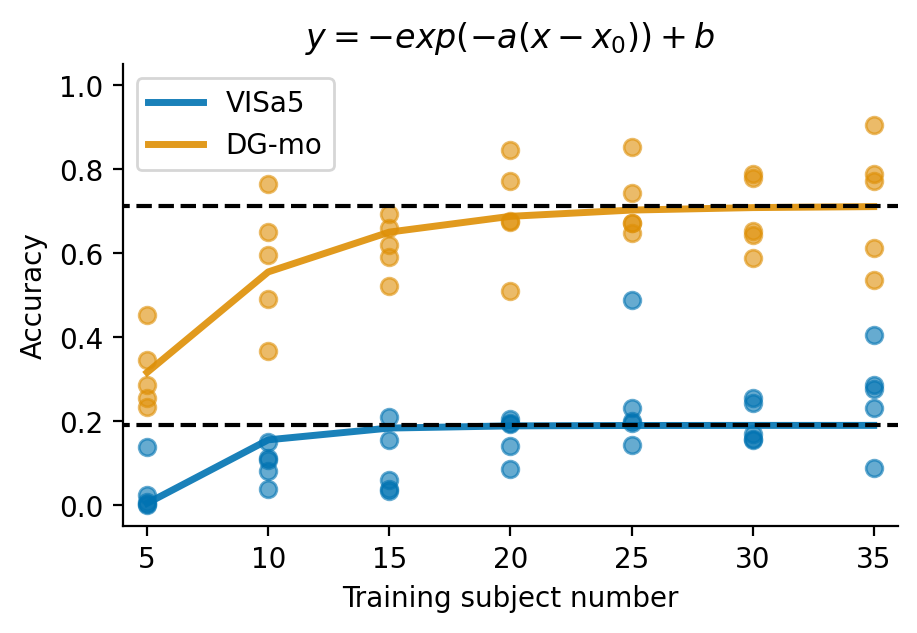

In [ ]:
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(5, 3), dpi=200)
sample_number = np.concatenate([5 * ii * np.ones(5) for ii in range(1, 8)])
for acronym_ii, acronym_test in enumerate(['VISa5', 'DG-mo']):
    acu = np.concatenate(acu_subject[acronym_test])

    plt.scatter(sample_number, acu, color=color_list[acronym_ii], alpha=0.6)
    popt, pcov = curve_fit(exp_func, sample_number, acu, p0=[1/100, 0.0, 0], bounds=([0, 0.0, 0], [np.inf, 1., np.inf]))
    print(popt)
    print(1/len(acu) * np.sqrt(np.sum(np.square(exp_func(sample_number, *popt) - acu))))
    plt.plot(sample_number, exp_func(sample_number, *popt), '-', color=color_list[acronym_ii], linewidth=2.5, alpha=0.9, label=acronym_test)
    plt.plot([0, 40], [popt[1], popt[1]], 'k--')

plt.xlabel(f'Training subject number')
plt.ylabel('Accuracy')
plt.ylim([-0.05, 1.05])
plt.xlim([4, 36])
sns.despine()
plt.legend(loc='best')
plt.title(f'$y = -exp(-a(x - x_0)) + b$')
plt.show()


[3.36932057e-01 1.90611159e-01 1.34669294e-21]
0.015480066568659532
[1.85165398e-01 7.13016167e-01 1.86745110e-15]
0.017199150344255495


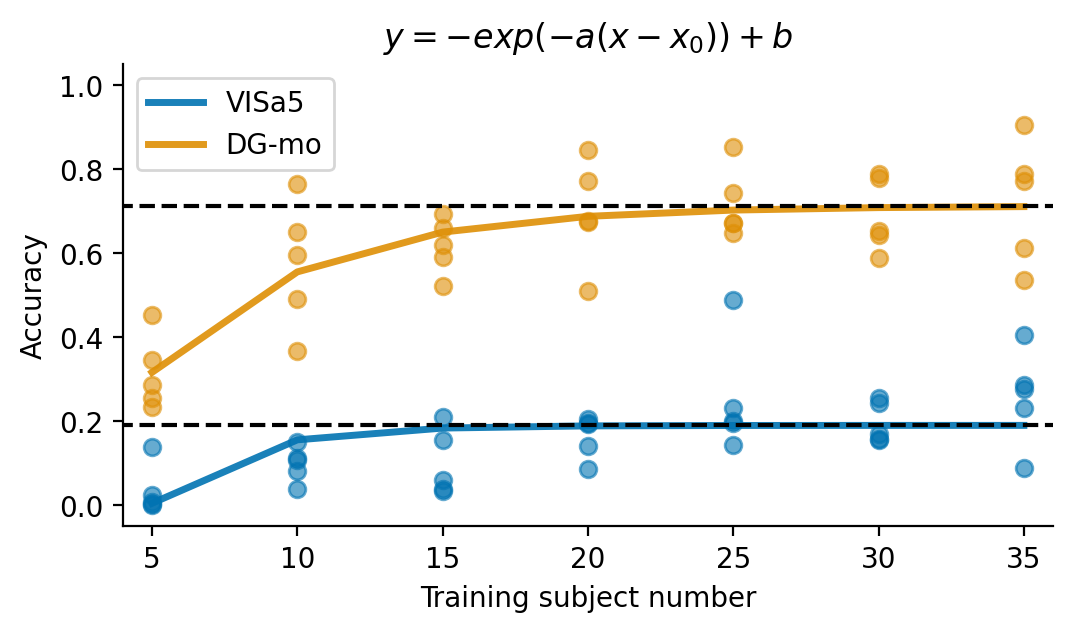

In [ ]:
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(6, 3), dpi=200)
sample_number = np.concatenate([5 * ii * np.ones(5) for ii in range(1, 8)])
for acronym_ii, acronym_test in enumerate(['VISa5', 'DG-mo']):
    acu = np.concatenate(acu_subject[acronym_test])

    plt.scatter(sample_number, acu, color=color_list[acronym_ii], alpha=0.6)
    popt, pcov = curve_fit(exp_func, sample_number, acu, p0=[1/100, 0.0, 0], bounds=([0, 0.0, 0], [np.inf, 1., np.inf]))
    print(popt)
    print(1/len(acu) * np.sqrt(np.sum(np.square(exp_func(sample_number, *popt) - acu))))
    plt.plot(sample_number, exp_func(sample_number, *popt), '-', color=color_list[acronym_ii], linewidth=2.5, alpha=0.9, label=acronym_test)
    plt.plot([0, 40], [popt[1], popt[1]], 'k--')

plt.xlabel(f'Training subject number')
plt.ylabel('Accuracy')
plt.ylim([-0.05, 1.05])
plt.xlim([4, 36])
sns.despine()
plt.legend(loc='best')
plt.title(f'$y = -exp(-a(x - x_0)) + b$')
plt.show()

In [ ]:
# color_list = sns.color_palette('colorblind')
# plt.figure(dpi=200)
# sample_number = np.concatenate([5 * ii * np.ones(5) for ii in range(1, 8)])
# for acronym_ii, acronym_test in enumerate(['VISa5', 'DG-mo']):
#     acu = np.concatenate(acu_subject[acronym_test])

#     plt.scatter(sample_number, acu, color=color_list[acronym_ii], alpha=0.6)
#     popt, pcov = curve_fit(exp_func, sample_number, acu, bounds=([0, 0.0, 0], [np.inf, 1., np.inf]))
#     print(popt)
#     plt.plot(sample_number, exp_func(sample_number, *popt), '-', color=color_list[acronym_ii], linewidth=2.5, alpha=0.9, label=acronym_test)
#     plt.plot([0, 40], [popt[1], popt[1]], 'k--')

# plt.xlabel(f'Training subject number')
# plt.ylabel('Accuracy')
# plt.ylim([-0.05, 1.05])
# plt.xlim([4, 36])
# sns.despine()
# plt.legend(loc='best')
# plt.title(f'$y = -exp(-a(x - x_0)) + b$')
# plt.show()


In [ ]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [ ]:
# sample_number = np.concatenate([5 * ii * np.ones(5) for ii in range(1, 8)])
# acu = np.concatenate(acu_subject[acronym_test])

# plt.figure(dpi=200)
# plt.scatter(sample_number, acu, color='blue', alpha=0.75)
# popt, pcov = curve_fit(exp_func, sample_number, acu, bounds=([0, 0.5, -1], [np.inf, 1., 0.0]))
# print(popt)
# plt.plot(sample_number, exp_func(sample_number, *popt), 'b--', linewidth=2.5, alpha=0.9, label='Electro')
# plt.xlabel(f'Training subject number ({acronym_test})')
# plt.ylabel('Accuracy')
# plt.ylim([-0.05, 1.05])
# sns.despine()
# plt.legend(loc='best')
# plt.show()